In [1]:
from google.colab import files
import numpy as np
import pandas as pd
import io
import matplotlib.pyplot as plt
%matplotlib inline
uploaded = files.upload()
hr_project_filename = next(iter(uploaded))
hr_project = pd.read_csv(io.BytesIO(uploaded[hr_project_filename]))
hr_project.head()

Saving hr_project.csv to hr_project.csv


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [2]:
print(hr_project.info())
display(hr_project.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB
None


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [3]:
# Check for missing values
print('Missing values per column:')
display(hr_project.isnull().sum())

Missing values per column:


,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_montly_hours,0
time_spend_company,0
Work_accident,0
left,0
promotion_last_5years,0
Department,0
salary,0


In [4]:
# Check class imbalance for the 'left' (target) column
print('Distribution of \'left\' column:')
display(hr_project['left'].value_counts(normalize=True))
print('\nDistribution of \'Department\' column:')
display(hr_project['Department'].value_counts(normalize=True))
print('\nDistribution of \'salary\' column:')
display(hr_project['salary'].value_counts(normalize=True))

Distribution of 'left' column:


,proportion
left,
0,0.761917
1,0.238083



Distribution of 'Department' column:


,proportion
Department,
sales,0.276018
technical,0.181345
support,0.148610
IT,0.081805
product_mng,0.060137
marketing,0.057204
RandD,0.052470
accounting,0.051137
hr,0.049270



Distribution of 'salary' column:


,proportion
salary,
low,0.487766
medium,0.429762
high,0.082472


In [5]:
from imblearn.under_sampling import RandomUnderSampler

X = hr_project.drop('left', axis=1)
y = hr_project['left']
rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X, y)
print('New distribution of \'left\' column after RandomUnderSampling:')
display(y_resampled.value_counts(normalize=True))

New distribution of 'left' column after RandomUnderSampling:


,proportion
left,
0,0.5
1,0.5


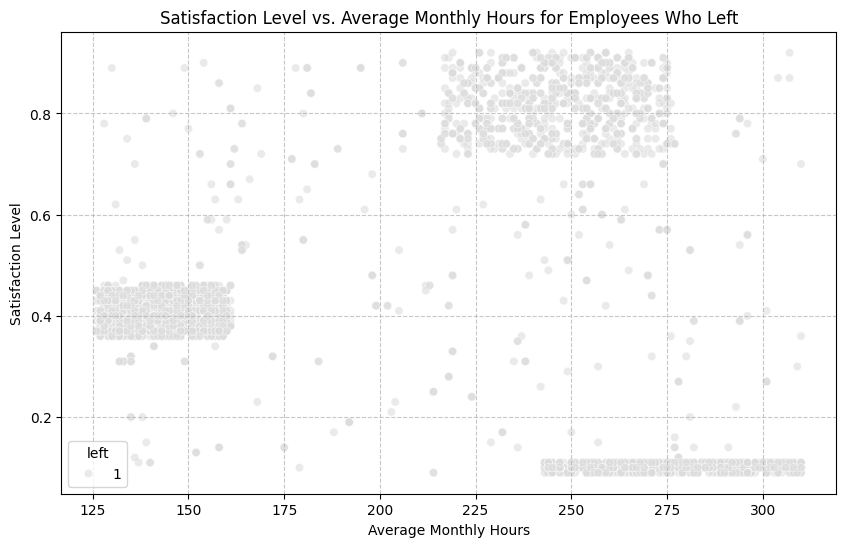

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter the original DataFrame for employees who left
employees_who_left = hr_project[hr_project['left'] == 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(x='average_montly_hours', y='satisfaction_level', data=employees_who_left, hue='left', palette='coolwarm', alpha=0.6)
plt.title('Satisfaction Level vs. Average Monthly Hours for Employees Who Left')
plt.xlabel('Average Monthly Hours')
plt.ylabel('Satisfaction Level')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

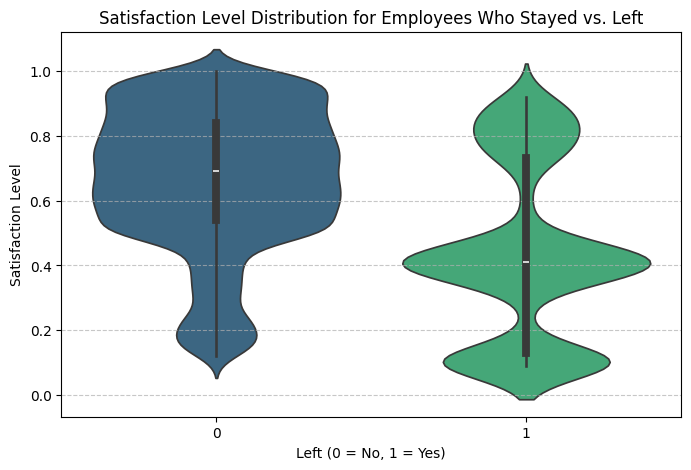

In [7]:
plt.figure(figsize=(8, 5))
sns.violinplot(x='left', y='satisfaction_level', data=hr_project, hue='left', palette='viridis', legend=False)
plt.title('Satisfaction Level Distribution for Employees Who Stayed vs. Left')
plt.xlabel('Left (0 = No, 1 = Yes)')
plt.ylabel('Satisfaction Level')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

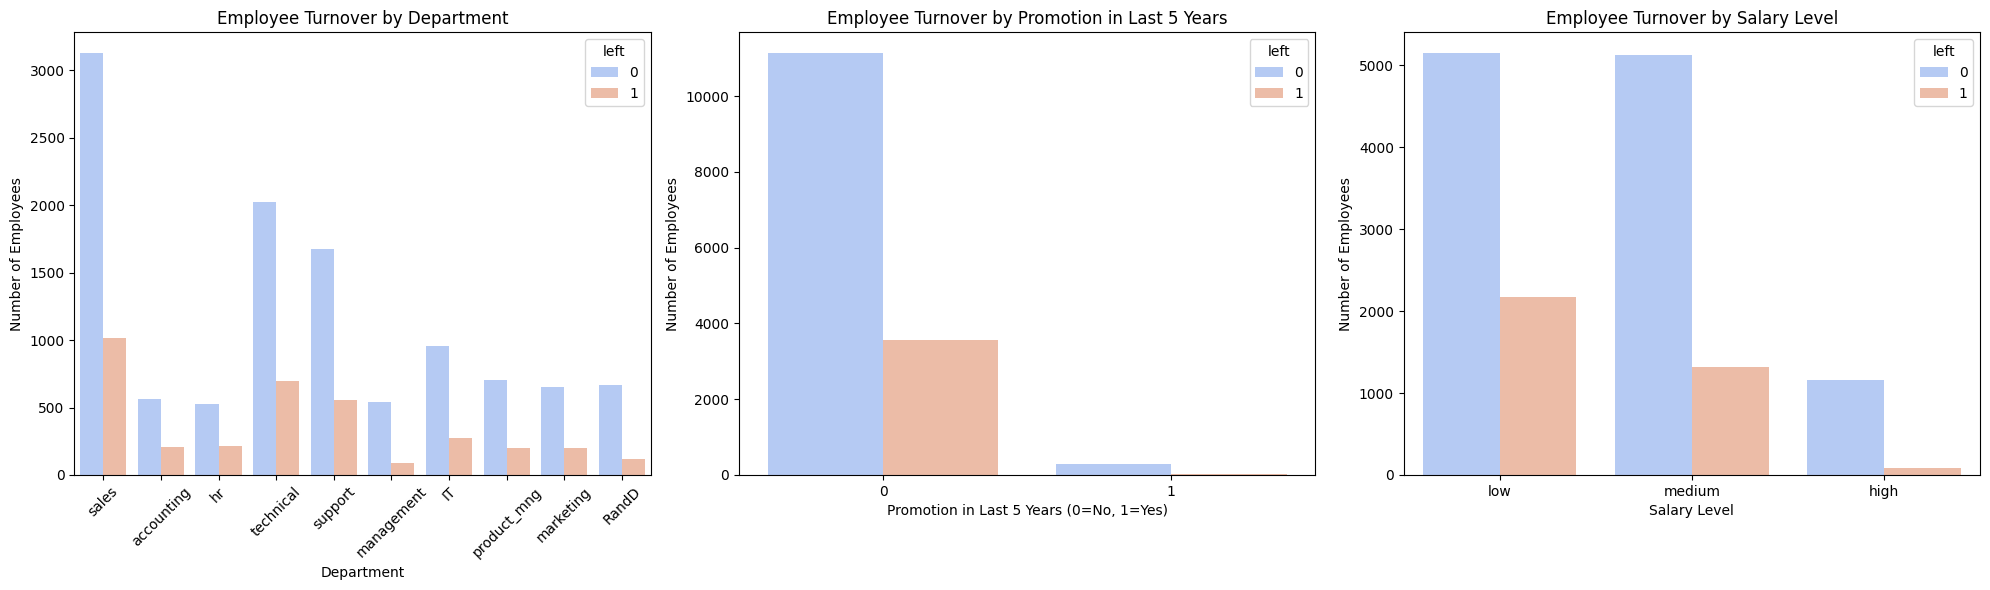

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.countplot(x='Department', hue='left', data=hr_project, palette='coolwarm', ax=axes[0])
axes[0].set_title('Employee Turnover by Department')
axes[0].set_xlabel('Department')
axes[0].set_ylabel('Number of Employees')
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(x='promotion_last_5years', hue='left', data=hr_project, palette='coolwarm', ax=axes[1])
axes[1].set_title('Employee Turnover by Promotion in Last 5 Years')
axes[1].set_xlabel('Promotion in Last 5 Years (0=No, 1=Yes)')
axes[1].set_ylabel('Number of Employees')

sns.countplot(x='salary', hue='left', data=hr_project, palette='coolwarm', ax=axes[2])
axes[2].set_title('Employee Turnover by Salary Level')
axes[2].set_xlabel('Salary Level')
axes[2].set_ylabel('Number of Employees')

plt.tight_layout()
plt.show()

In [9]:
# Identify categorical columns
categorical_cols = ['Department', 'salary']
hr_project_encoded = pd.get_dummies(hr_project, columns=categorical_cols, drop_first=True)
print("DataFrame after one-hot encoding:")
display(hr_project_encoded.head())

DataFrame after one-hot encoding:


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,False,False,False,False,False,False,True,False,False,True,False
1,0.80,0.86,5,262,6,0,1,0,False,False,False,False,False,False,True,False,False,False,True
2,0.11,0.88,7,272,4,0,1,0,False,False,False,False,False,False,True,False,False,False,True
3,0.72,0.87,5,223,5,0,1,0,False,False,False,False,False,False,True,False,False,True,False
4,0.37,0.52,2,159,3,0,1,0,False,False,False,False,False,False,True,False,False,True,False


In [10]:
from sklearn.model_selection import train_test_split
X_encoded = hr_project_encoded.drop('left', axis=1)
y = hr_project_encoded['left']
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (10499, 18)
Shape of X_test: (4500, 18)
Shape of y_train: (10499,)
Shape of y_test: (4500,)


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Initialize the Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Logistic Regression Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred), index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

Logistic Regression Model Performance:
Accuracy: 0.7936
Precision: 0.6096
Recall: 0.3688
F1-Score: 0.4596

Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,3176,253
Actual 1,676,395


In [12]:
from sklearn.ensemble import RandomForestClassifier
#Initialize the Random Forest Classification model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("Random Forest Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")
print("\nConfusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_rf), index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

Random Forest Model Performance:
Accuracy: 0.9900
Precision: 0.9933
Recall: 0.9645
F1-Score: 0.9787

Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,3422,7
Actual 1,38,1033


In [13]:
feature_importances = rf_model.feature_importances_
features = X_encoded.columns

importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Top 10 Feature Importances from Random Forest Model:")
display(importance_df.head(10))

Top 10 Feature Importances from Random Forest Model:


,Feature,Importance
0,satisfaction_level,0.312459
4,time_spend_company,0.187550
2,number_project,0.180202
3,average_montly_hours,0.151679
1,last_evaluation,0.125491
5,Work_accident,0.009911
16,salary_low,0.007774
17,salary_medium,0.003945
13,Department_sales,0.003411
15,Department_technical,0.003401


/tmp/ipykernel_469/2878448118.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')


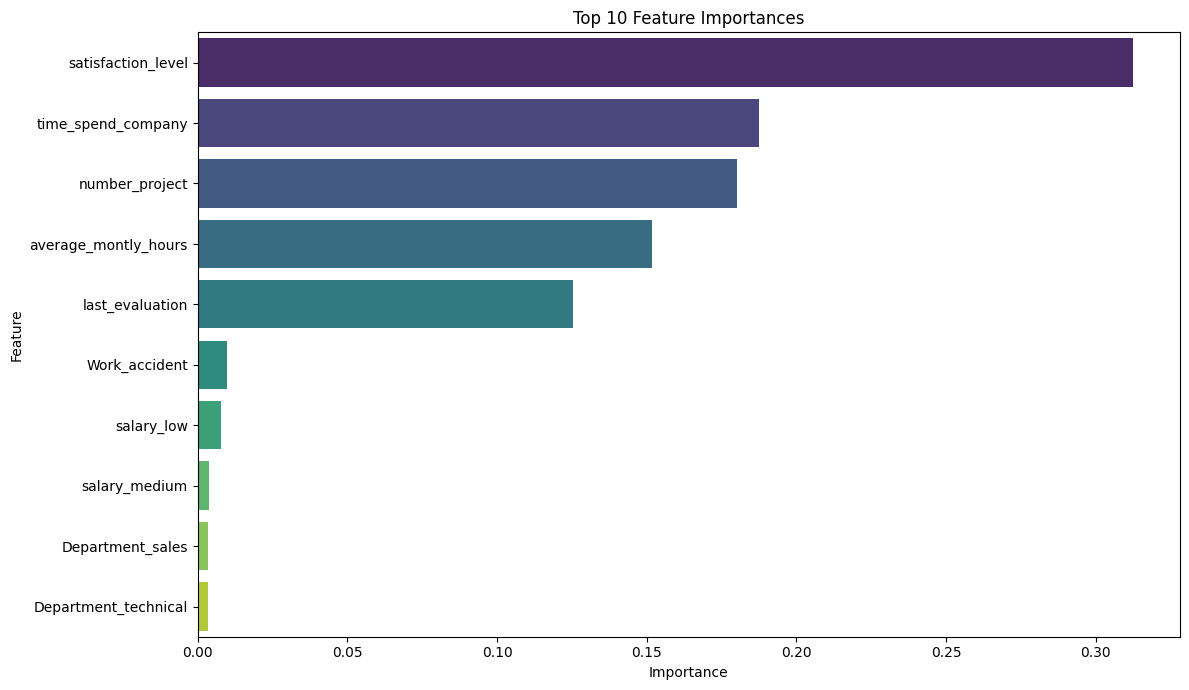

In [14]:
# Visualize feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()